In [1]:
import numpy as np

In [35]:
theta = 67.983
middle = 180
degrees_0 = middle+theta/2
degrees_1 = middle+theta/6
degrees_2 = middle-theta/6
degrees_3 = middle-theta/2

rad = lambda deg: deg * (np.pi / 180)
print(rad(degrees_0))
print(rad(degrees_1))
print(rad(degrees_2))
print(rad(degrees_3))

-2.5483290608981406
-2.9438381226925756
-3.3393471844870106
-3.7348562462814456


In [36]:
angle_min= -3.1241390705108643
angle_max= 3.1415927410125732
angle_increment= 0.005806980188935995
i=0
while True:
    angle = angle_min + angle_increment * i
    if angle > rad(degrees_3): break
    i += 1
print('zone 3')
while True:
    angle = angle_min + angle_increment * i
    if angle > rad(degrees_2): break
    print(i, end=' ')
    i += 1
print('\nzone 2')
while True:
    angle = angle_min + angle_increment * i
    if angle > rad(degrees_1): break
    print(i, end=' ')
    i += 1
print('\nzone 1')
while True:
    angle = angle_min + angle_increment * i
    if angle > rad(degrees_0): break
    print(i, end=' ')
    i += 1

zone 3

zone 2
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 
zone 1
32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 

In [19]:
import sys
import os
import time
import PIL
import glob
sys.path.append(os.getcwd())
image_list = []
class Camera:
    def __init__(self, camera=0):
        self.set_camera(camera)
    def set_camera(self, camera):
        if isinstance(camera, str):
            if os.path.exists(os.path.expanduser(camera)):
                self.camera = 'local'
                self.image_list = glob.glob(os.path.join(camera, '*.png'))
                print(len(self.image_list))
    def get_frame(self, stamp=time.time()):
        if self.camera == 'local':
            while True:
                self.frame = PIL.Image.open(self.image_list.pop(0))
                if self.frame is not None:
                    break
        return self.frame
fd = ('./images/images')
cam = Camera(fd)

1025


In [16]:
import os
import time
from datetime import datetime
from builtin_interfaces.msg import Time
import glob
import PIL.Image

def make_utc(filename):
    filename = os.path.basename(filename).split('.')[0]
    yymmdd, hhmmss, ms = filename.split('_')
    utc = time.mktime(time.strptime(yymmdd+hhmmss, '%y%m%d%H%M%S'))
    return float(str(int(utc)) + '.' + ms)

fd = ('./images/images')
image_list = glob.glob(os.path.join(fd, '*.png'))
last_utc = make_utc(image_list[0])


def get_frame(stamp=time.time()):
    stamp = stamp.sec + stamp.nanosec * 1e-9
    while True:
        curr_ = make_utc(image_list[0])
        next_ = make_utc(image_list[1])
        if next_ > stamp: break
        image_list.pop(0)
    print(curr_, stamp, next_)
    frame = PIL.Image.open(image_list[0])
    print(stamp, next_)
    return frame

1717997887.0003672 ./images/images/240610_143910_24.png 1717998095.17
1717997887.0046573 ./images/images/240610_144135_17.png 1717997956.04
1717997887.0056393 ./images/images/240610_143916_04.png 1717998083.77
1717997887.0067441 ./images/images/240610_144123_77.png 1717998115.37


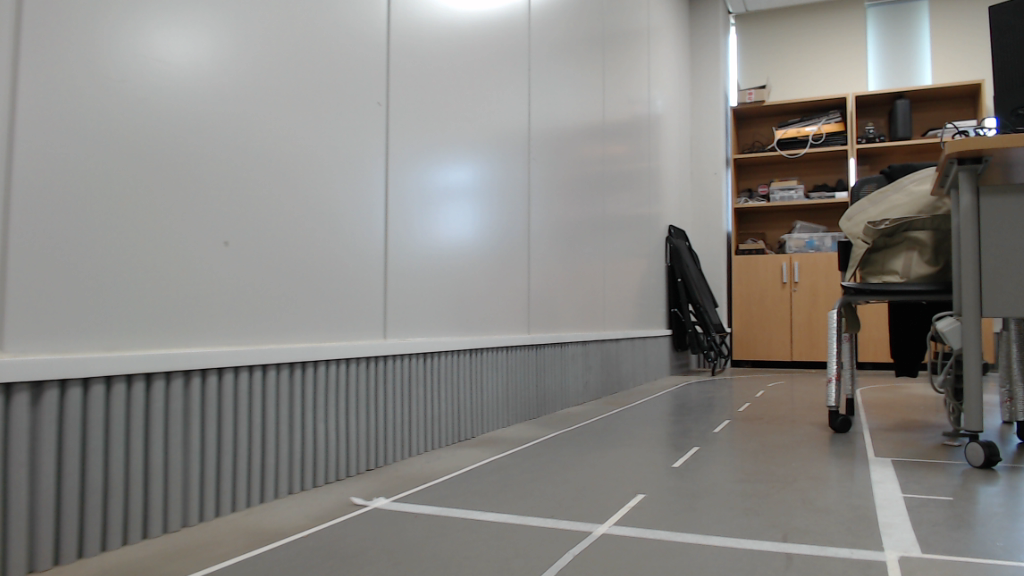

In [18]:
t = Time()
t.sec=1717997887
t.nanosec=367183
get_frame(t)
t.sec=1717997887
t.nanosec=4657204
get_frame(t)
t.sec=1717997887
t.nanosec=5639324
get_frame(t)
t.sec=1717997887
t.nanosec=6744037
get_frame(t)

In [ ]:
from builtin_interfaces.msg import Time

def time_to_float(time):
    return time.sec + time.nanosec * 1e-9

# Example usage
time = Time(sec=1639568400, nanosec=500000000)
float_time = time_to_float(time)
print(float_time)

zone 3

zone 2
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 
zone 1
32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 
66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 